# Week 6 - K-Means Clustering

**Goal:** Apply K-means clustering to the same dataset, determine a good number of clusters, and then compare K-means with your previous clustering models using multiple internal evaluation criteria to decide which method provides the most useful clustering structure.

## A. Setup + Data Preparation

### 0. Setup

In [29]:
import os
import sys
import platform
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())
print('pandas:', pd.__version__)

Python: 3.13.1
Platform: Windows-10-10.0.19045-SP0
pandas: 3.0.1


In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd() / "no_show_predict"
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"
CONFIGS = PROJECT_ROOT / "configs"

PROJECT_ROOT

WindowsPath('c:/Users/Vivi/Documents/Repos/Data-Science/no_show_predict')

### 1. Load Dataset

In [4]:
data_path = DATA_PROCESSED / "appointments_processed.csv"
data = pd.read_csv(data_path)
print(data.shape)
data.head()

(110527, 15)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMSReceived,NoShow,WaitingDays
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,False,True,False,False,False,False,False,0
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,False,False,False,False,False,False,False,0
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,False,False,False,False,False,False,False,0
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,False,False,False,False,False,False,False,0
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,False,True,True,False,False,False,False,0


### 2. Define Feature Matrix

Numeric features only

In [5]:
x = (
    data
    .drop(columns = ["NoShow"])
    .select_dtypes(include = ["number", "bool"])
    .astype(float)
)

print("Number of features:", x.shape[1])
print("Feature names:")
for col in x.columns:
    print("-", col)

Number of features: 10
Feature names:
- PatientId
- AppointmentID
- Age
- Scholarship
- Hypertension
- Diabetes
- Alcoholism
- Handicap
- SMSReceived
- WaitingDays


### 3. Standardize Features

In [6]:
prep = Pipeline([
    ("scaler", StandardScaler())
])

x_scaled = prep.fit_transform(x)

### 4. Clustering Evaluation Criteria

**Chosen Metrics:**
- Silhouette Score
- Calinski-Harabasz Index
- Davies-Bouldin Index

## B. K-Means Clustering

### B1. Initial K-Means Model

In [16]:
def run_kmeans(k = 3):
    kmeans = KMeans(
        n_clusters = k,
        random_state = 42,
        n_init = 10
    )
    labels = kmeans.fit_predict(x_scaled)
    cluster_sizes = pd.Series(labels).value_counts().sort_index()

    # Evaluation
    sil_score = silhouette_score(x_scaled, labels)
    ch_score = calinski_harabasz_score(x_scaled, labels)
    db_score = davies_bouldin_score(x_scaled, labels)

    return {
        "k": k,
        "inertia": kmeans.inertia_,
        "cluster_sizes": cluster_sizes,
        "sil_score": sil_score,
        "ch_score": ch_score,
        "db_score": db_score
    }

In [15]:
def print_report(results):
    print("- K:", results["k"])
    print("- Inertia:", results["inertia"])
    print("- Cluster Sizes:")
    for size in results["cluster_sizes"]:
        print("\t-", size)
    print("- Silhouette Score:", results["sil_score"])
    print("- Calinski-Harabasz Index:", results["ch_score"])
    print("- Davies-Bouldin Index:", results["db_score"])

In [17]:
k = 3
results_initial_kmeans = run_kmeans(k = k)


In [18]:
print_report(results_initial_kmeans)

- K: 3
- Inertia: 816491.8456404497
- Cluster Sizes:
	- 29212
	- 59666
	- 21649
- Silhouette Score: 0.22535497594271447
- Calinski-Harabasz Index: 19545.208825014524
- Davies-Bouldin Index: 1.7004073381618479


### B2. Choosing the Number of Clusters

In [19]:
k_vals = [ 2, 4, 5, 6 ]
results = []

for k in k_vals:
    result = run_kmeans(k = k)
    results.append(result)

In [21]:
for i in range(4):
    print(f"Model {i+1}:")
    print_report(results[i])
    print()

Model 1:
- K: 2
- Inertia: 940115.9079679073
- Cluster Sizes:
	- 23233
	- 87294
- Silhouette Score: 0.2985327041548291
- Calinski-Harabasz Index: 19416.38938049071
- Davies-Bouldin Index: 1.8885043502109218

Model 2:
- K: 4
- Inertia: 713052.3706050629
- Cluster Sizes:
	- 58259
	- 20321
	- 28588
	- 3359
- Silhouette Score: 0.25024577466391024
- Calinski-Harabasz Index: 20264.638312379895
- Davies-Bouldin Index: 1.4424599088767507

Model 3:
- K: 5
- Inertia: 624545.7262182123
- Cluster Sizes:
	- 19250
	- 10163
	- 53167
	- 2241
	- 25706
- Silhouette Score: 0.27835640292080727
- Calinski-Harabasz Index: 21267.79224455938
- Davies-Bouldin Index: 1.2778740194689902

Model 4:
- K: 6
- Inertia: 527735.6000297504
- Cluster Sizes:
	- 20760
	- 56521
	- 18093
	- 9632
	- 3280
	- 2241
- Silhouette Score: 0.3127889595486995
- Calinski-Harabasz Index: 24190.077985357475
- Davies-Bouldin Index: 1.1354612201832823



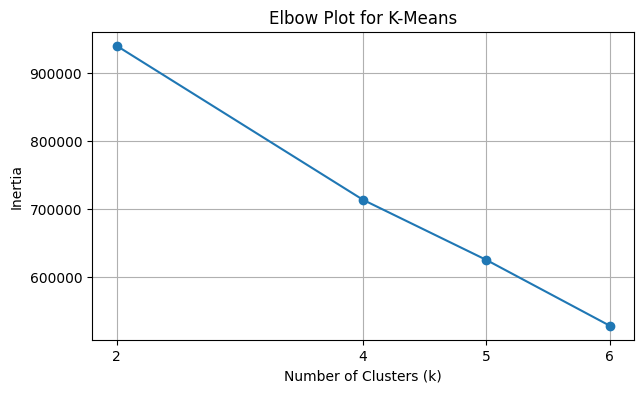

In [23]:
results_df = pd.DataFrame(results)
plt.figure(figsize = (7, 4))
plt.plot(results_df["k"], results_df["inertia"], marker = "o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Plot for K-Means")
plt.xticks(k_vals)
plt.grid(True)
plt.show()

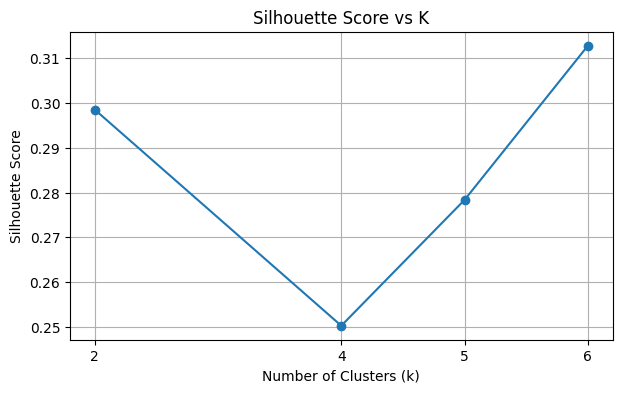

In [24]:
plt.figure(figsize = (7, 4))
plt.plot(results_df["k"], results_df["sil_score"], marker = "o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.xticks(k_vals)
plt.grid(True)
plt.show()

In [25]:
best_sil_k = results_df.loc[results_df["sil_score"].idxmax(), "k"]
best_ch_k = results_df.loc[results_df["ch_score"].idxmax(), "k"]
best_db_k = results_df.loc[results_df["db_score"].idxmax(), "k"]

print("Best k by Sihouette Score:", best_sil_k)
print("Best k by Calinski-Harabasz Index:", best_ch_k)
print("Best k by Davies-Boulding Index:", best_db_k)


Best k by Sihouette Score: 6
Best k by Calinski-Harabasz Index: 6
Best k by Davies-Boulding Index: 2


**Interpretation:**<br/>
The elbow plot shows no significant bends at any of the tested `k` values, but both the Silhouette score and the Calinski-Harabasz index seem to aggree on `k = 6` being the optimal value from those tested, with only the Davies-Boulding index disaggreeing and picking `k = 2`.

## C. Interpretation of K-Means Clusters

**Best K-Means Configuration:** `k = 6`

In [27]:
best_k = 6
best_kmeans = KMeans(
    n_clusters = best_k,
    random_state = 42,
    n_init = 10
)
best_labels = best_kmeans.fit_predict(x_scaled)
best_cluster_sizes = pd.Series(best_labels).value_counts().sort_index()

best_centroids = pd.DataFrame(
    prep.named_steps["scaler"].inverse_transform(
        best_kmeans.cluster_centers_
    ),
    columns = x.columns
)
best_centroids.index = [f"Cluster {i}" for i in range(best_k)]

In [28]:
print("Best Model:")
print("- K", best_k)
print("- Cluster Sizes:")
for size in best_cluster_sizes:
    print("\t-", size)
print("- Cluster Centroids:")
display(best_centroids)

Best Model:
- K 6
- Cluster Sizes:
	- 20760
	- 56521
	- 18093
	- 9632
	- 3280
	- 2241
- Cluster Centroids:


,PatientId,AppointmentID,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMSReceived,WaitingDays
Cluster 0,1.453670e+14,5.582974e+06,34.518270,6.999083e-03,0.063378,0.011392,9.653907e-05,1.307982e-15,0.748805,31.257325
Cluster 1,1.491075e+14,5.702208e+06,30.437856,-1.308675e-14,0.000088,0.000424,-2.824130e-15,-2.300243e-15,0.182561,3.347265
Cluster 2,1.454288e+14,5.689568e+06,61.242885,2.111080e-02,0.939983,0.377950,-1.179612e-16,1.228184e-15,0.285714,5.953357
Cluster 3,1.442997e+14,5.682684e+06,28.947051,1.000000e+00,0.126869,0.013185,6.869505e-16,7.251144e-16,0.322778,7.493044
Cluster 4,1.644844e+14,5.689083e+06,49.496037,1.597561e-01,0.391463,0.096951,1.000000e+00,-1.214306e-16,0.252439,6.192988
Cluster 5,1.320818e+14,5.682801e+06,50.541722,7.942883e-02,0.431950,0.178046,3.480589e-02,1.000000e+00,0.239179,7.379295


In [ ]:
pca = PCA(n_components = 2)
x_pca = pca.fit_transform(x_scaled)

pca_df = pd.DataFrame(x_pca, columns = ["PC1", "PC2"])
pca_df["Cluster"] = best_labels

plt.figure(figsize = (8, 6))

## D. Comparison with Previous Clustering Models

### D1. Comparison Table

### D2. Analysis of Results